# Examples for processing Abacus data
For detailed documentation about AbacusSummit, visit https://abacussummit.readthedocs.io/

First, we use the `jax-hod` convenience function for loading AbacusSummit halo catalogs from NERSC and then plot the halo mass function.

In [1]:
import gc
from jaxhod import load_abacus_halos
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

SIM_DIR = '/global/cfs/cdirs/desi/public/cosmosim/AbacusSummit'

def get_halos(cosmo=0, phase=0, redshift=0.5):
    return load_abacus_halos(
        sim_dir=SIM_DIR,
        cosmology=f'c{cosmo:03}',
        phase=f'ph{phase:03}',
        redshift=0.5,
    )

def plot_hmf(halos, show=False, label=None):
    bins = np.logspace(10.5, 16, 101)
    hist, bin_edges = np.histogram(halos['masses'], bins=bins)
    
    dlog10M = np.diff(np.log10(bins))
    volume = 2000.0**3.0
    
    massfunc = hist / (dlog10M * volume)
    mass = np.sqrt(bins[:-1] * bins[1:])
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(mass, massfunc, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{\rm halo}\,[h^{-1}M_\odot]$')
    ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\log_{10}M\;[h^{3}\,\mathrm{Mpc}^{-3}]$')
    if label is not None:
        ax.legend()
    if show:
        plt.show()
        return
    return ax, fig

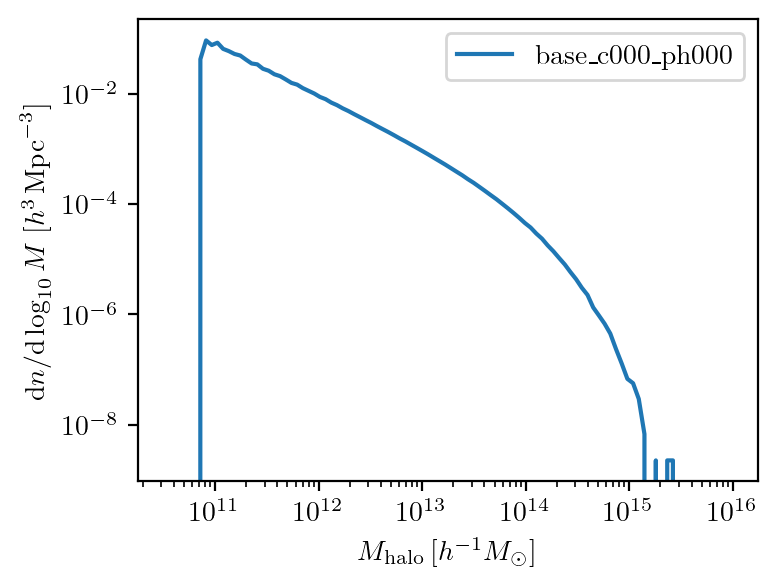

In [2]:
halos = get_halos(cosmo=0, phase=0, redshift=0.5)

plot_hmf(halos, show=True, label=r'$\textrm{base_c000_ph000}$')

We can also load a subsampled set of the halos that will be more efficient for HOD sampling. The subsample contains weights that retain information about what is the true number density of halos from the full catalog, which can be used to correct statistics that explicitly depend on the true density.

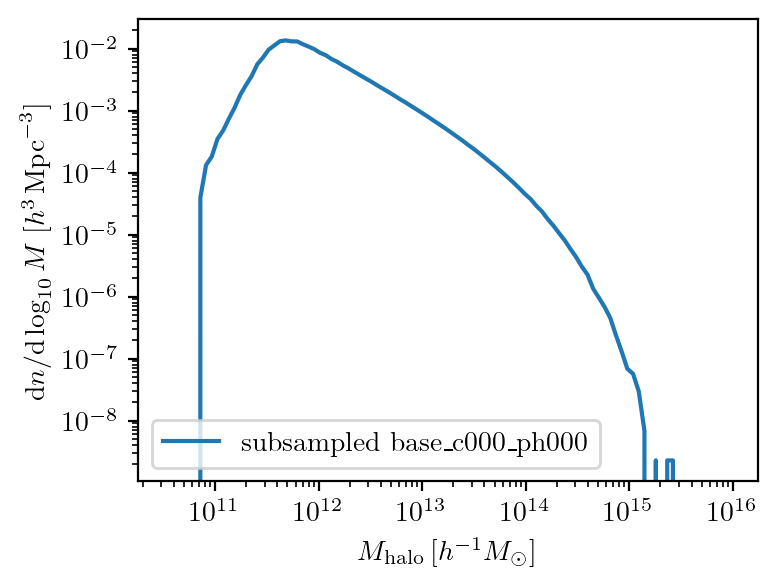

In [2]:
from jaxhod.simulations import load_abacus_subsampled_halos

def get_subsampled_halos(cosmo=0, phase=0, redshift=0.5):
    return load_abacus_subsampled_halos(
    subsample_dir='/pscratch/sd/e/epaillas/summit_subsamples/boxes/base',
    sim_dir=SIM_DIR,
    cosmology=f'c{cosmo:03}',
    phase=f'ph{phase:03}',
    redshift=0.5,
    )

subsampled_halos = get_subsampled_halos(cosmo=0, phase=0, redshift=0.5)

plot_hmf(subsampled_halos, show=True, label=r'subsampled $\textrm{base_c000_ph000}$')

## HOD galaxy catalog

Next, we populate the AbacusSummit halos with galaxies using the Zheng et al. (2007) HOD model. We use `jax-hod`'s `Zheng07` class to define the model parameters and the `populate` function to draw
galaxy positions from the halo catalog.

In [4]:
import jax
from jaxhod import Zheng07, populate

# Zheng+07 HOD parameters (tuned to a typical BOSS-like galaxy sample)
hod_params = dict(
    log_Mmin=13.1,
    sigma_logM=0.35,
    log_M0=13.1,
    log_M1=14.2,
    alpha=1.0,
)

model = Zheng07(**hod_params)

# Populate the halo catalog with galaxies
key = jax.random.PRNGKey(42)
galaxies = populate(
    halo_positions=subsampled_halos['positions'],
    halo_masses=subsampled_halos['masses'],
    halo_radii=subsampled_halos['radii'],
    model=model,
    key=key,
    batch_size=1_000_000,
    jit=True,
)

n_cen = galaxies['is_central'].sum()
n_sat = (~galaxies['is_central']).sum()
n_tot = len(galaxies['positions'])

print(f"Total galaxies  : {n_tot:,}")
print(f"  Centrals      : {n_cen:,}  ({100*n_cen/n_tot:.1f}%)")
print(f"  Satellites    : {n_sat:,}  ({100*n_sat/n_tot:.1f}%)")
print(f"Number density  : {n_tot / 2000.0**3:.3e}  h^3 Mpc^-3")

Total galaxies  : 2,662,334
  Centrals      : 2,434,382  (91.4%)
  Satellites    : 227,952  (8.6%)
Number density  : 3.328e-04  h^3 Mpc^-3
